In [2]:
import os
from google.colab import userdata

# Inject credentials directly into system environment variables
os.environ['KAGGLE_USERNAME'] = ('poojariaditi')
os.environ['KAGGLE_KEY'] = ('KGAT_a09b958b2b141f79f04b29bcfc0b65bf')

In [3]:
# Pull down target dataset archive
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

# Extract assets quietly into the project target directory
!unzip -q new-plant-diseases-dataset.zip -d /content/plant_data_source/

# Purge structural remnants to conserve system resource space
!rm new-plant-diseases-dataset.zip

print("Successfully retrieved and partitioned dataset targets.")

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [02:41<00:00, 17.9MB/s]

Successfully retrieved and partitioned dataset targets.


In [4]:
import os
from PIL import Image

# Establish working dataset split mappings
training_assets_path = '/content/plant_data_source/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
validation_assets_path = '/content/plant_data_source/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

def filter_and_verify_images(target_path):
    print(f"Beginning corruption scan inside: {target_path}")
    deleted_files_count = 0

    # Traverse file structure systematically
    for root_dir, _, source_files in os.walk(target_path):
        for each_file in source_files:
            if each_file.lower().endswith(('jpg', 'jpeg', 'png')):
                full_file_loc = os.path.join(root_dir, each_file)
                try:
                    with Image.open(full_file_loc) as verified_img:
                        verified_img.verify() # Validate internal file byte schema
                except (IOError, SyntaxError):
                    print(f"Removing corrupted image item: {full_file_loc}")
                    os.remove(full_file_loc)
                    deleted_files_count += 1

    print(f"Directory scan finished. Total purged: {deleted_files_count}\n")

# Execute integrity tests
filter_and_verify_images(training_assets_path)
filter_and_verify_images(validation_assets_path)

# Verify structural subset balance
target_labels = os.listdir(training_assets_path)
print(f"Total confirmed unique biological target labels: {len(target_labels)}")

Beginning corruption scan inside: /content/plant_data_source/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Directory scan finished. Total purged: 0

Beginning corruption scan inside: /content/plant_data_source/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Directory scan finished. Total purged: 0

Total confirmed unique biological target labels: 38


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Instantiating batch processing configuration scaling definitions
scaling_generator = ImageDataGenerator(rescale=1.0/255.0)

# Build out concrete runtime generators mapping down paths
train_stream = scaling_generator.flow_from_directory(
    training_assets_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_stream = scaling_generator.flow_from_directory(
    validation_assets_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Load pre-trained neural network framework without the final fully-connected block
backbone_network = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
backbone_network.trainable = False # Protect existing convolutional weights

# Assemble structural pipeline configurations
plant_classifier_model = Sequential([
    backbone_network,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(38, activation='softmax') # Map outputs out to the 38 plant variants
])

# Prepare configuration targets for optimization operations
plant_classifier_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

plant_classifier_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

# Create criteria setup ensuring process safety against baseline plateau behaviors
overfit_guard = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Commencing optimization computations
runtime_history = plant_classifier_model.fit(
    train_stream,
    validation_data=validation_stream,
    epochs=5,
    callbacks=[overfit_guard]
)

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 205s 84ms/step - accuracy: 0.8601 - loss: 0.4479 - val_accuracy: 0.9417 - val_loss: 0.1846
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 141s 64ms/step - accuracy: 0.9246 - loss: 0.2226 - val_accuracy: 0.9455 - val_loss: 0.1600
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 151s 69ms/step - accuracy: 0.9368 - loss: 0.1830 - val_accuracy: 0.9471 - val_loss: 0.1564
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 136s 62ms/step - accuracy: 0.9446 - loss: 0.1589 - val_accuracy: 0.9538 - val_loss: 0.1382
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 149s 68ms/step - accuracy: 0.9515 - loss: 0.1391 - val_accuracy: 0.9533 - val_loss: 0.1376


In [8]:
# Export the functional configuration matrix to an .h5 archive structure
plant_classifier_model.save('botanical_diagnostic_mobilenetv2.h5')

print("Trained system structural data saved to botanical_diagnostic_mobilenetv2.h5 successfully.")

Trained system structural data saved to botanical_diagnostic_mobilenetv2.h5 successfully.


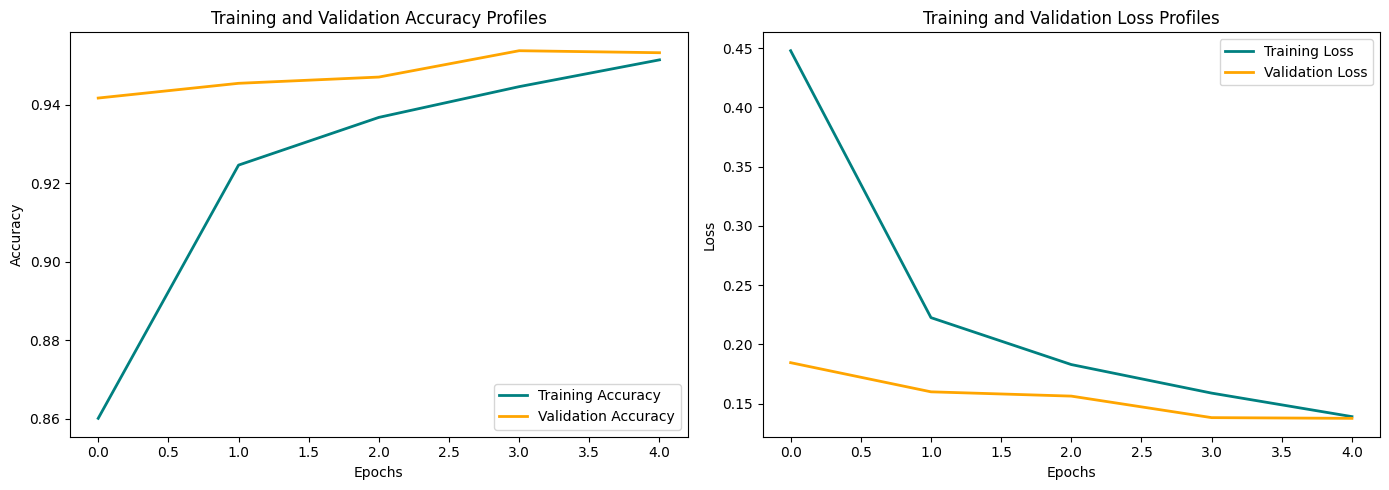

In [9]:
import matplotlib.pyplot as plt

# Extract historic metrics from the optimization runtime
acc = runtime_history.history['accuracy']
val_acc = runtime_history.history['val_accuracy']
loss = runtime_history.history['loss']
val_loss = runtime_history.history['val_loss']
epochs_range = range(len(acc))

# Render structural diagnostics visualization
plt.figure(figsize=(14, 5))

# Plot Accuracy Trends
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='teal', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy Profiles')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Plot Loss Trends
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='teal', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss Profiles')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# 1. Create a clean lookup dictionary to map indices back to the actual class names
# Uses your actual training stream variable: train_stream
class_indices = train_stream.class_indices
labels_lookup = {v: k for k, v in class_indices.items()}

def predict_plant_disease(img_path):
    # Load and preprocess the image exactly how the model expects it
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Remember to rescale pixel values!

    # Run the image through the network using your actual model name
    predictions = plant_classifier_model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx] * 100

    # Clean up the raw directory label text format for the visual display
    raw_label = labels_lookup[predicted_class_idx]
    clean_label = raw_label.replace("___", " - ").replace("_", " ")

    # Display the leaf image alongside the prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {clean_label}\nConfidence: {confidence:.2f}%",
              fontsize=12, color='green', weight='bold', pad=10)
    plt.show()

# 2. Pick a random test image from your unzipped test folder to run a trial
# Note: Check your sidebar folder view to confirm the exact name of your test folder path!
sample_test_image = "/content/dataset/New Plant Diseases Dataset(Augmented)/test/test/TomatoEarlyBlight1.JPG"

# Run prediction with automated directory fallback reporting
try:
    predict_plant_disease(sample_test_image)
except Exception as e:
    print(f"Execution Error: {e}\n")
    print("Double check your sample path! Here are some files available in your test directory:")
    test_dir_check = "/content/dataset/New Plant Diseases Dataset(Augmented)/test/test"
    if os.path.exists(test_dir_check):
        available_files = [f for f in os.listdir(test_dir_check) if not f.startswith('.')]
        print(available_files[:5])
    else:
        print(f"❌ Directory path '{test_dir_check}' could not be located on disk.")

Execution Error: [Errno 2] No such file or directory: '/content/dataset/New Plant Diseases Dataset(Augmented)/test/test/TomatoEarlyBlight1.JPG'

Double check your sample path! Here are some files available in your test directory:
❌ Directory path '/content/dataset/New Plant Diseases Dataset(Augmented)/test/test' could not be located on disk.


Please upload a leaf image file (.jpg, .jpeg, .png) from your device:


Saving OIP (1).jpg to OIP (1).jpg

Processing uploaded asset: OIP (1).jpg


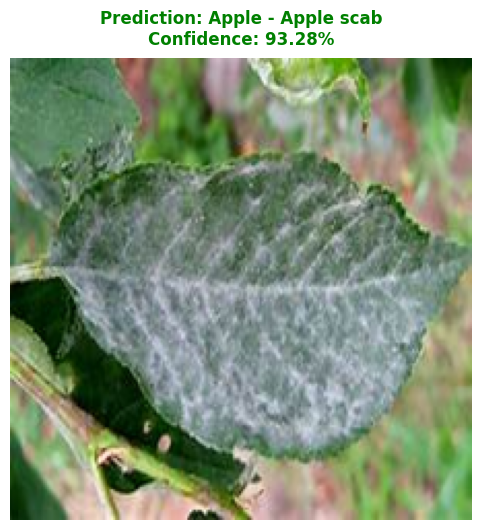

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files
from PIL import Image

# 1. Create a clean lookup dictionary to map indices back to the actual class names
class_indices = train_stream.class_indices
labels_lookup = {v: k for k, v in class_indices.items()}

def predict_uploaded_plant_specimen():
    try:
        # 2. Trigger Google Colab Browser Upload Widget
        print("Please upload a leaf image file (.jpg, .jpeg, .png) from your device:")
        uploaded_bundles = files.upload()

        if not uploaded_bundles:
            print("Upload cancelled by user.")
            return

        # Extract the dynamically generated filename
        uploaded_file_name = list(uploaded_bundles.keys())[0]
        print(f"\nProcessing uploaded asset: {uploaded_file_name}")

        # 3. Load and preprocess the image file safely using PIL
        raw_img = Image.open(uploaded_file_name).convert('RGB').resize((224, 224))
        img_array = image.img_to_array(raw_img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0  # Crucial pixel normalization scaling

        # 4. Run the image through the network using your precise model name
        predictions = plant_classifier_model.predict(img_array, verbose=0)
        predicted_class_idx = np.argmax(predictions[0])
        confidence = predictions[0][predicted_class_idx] * 100

        # Clean up the raw directory label text format for the visual display
        raw_label = labels_lookup[predicted_class_idx]
        clean_label = raw_label.replace("___", " - ").replace("_", " ")

        # 5. Render the exact target output layout
        plt.figure(figsize=(6, 6))
        plt.imshow(raw_img)
        plt.axis('off')
        plt.title(f"Prediction: {clean_label}\nConfidence: {confidence:.2f}%",
                  fontsize=12, color='green', weight='bold', pad=10)
        plt.show()

        # Delete file out of your storage workspace when finished to keep it tidy
        os.remove(uploaded_file_name)

    except Exception as e:
        print(f"Execution Error: {e}")

# Run the upload and prediction workflow
predict_uploaded_plant_specimen()

In [40]:
import json

# Compile label indexing directly from your active training flow
labels_schema = train_stream.class_indices

# Export as an independent structural JSON file tracking parameters
with open('botanical_labels.json', 'w') as f:
    json.dump(labels_schema, f)

print("✅ 'botanical_labels.json' successfully generated and saved to environment workspace!")

✅ 'botanical_labels.json' successfully generated and saved to environment workspace!


⚡ Scanning remote repository sources for fresh test specimens...
✅ Automated scanning complete! Images staged successfully without manual uploads.

🔄 Running batch inference on 6 random test images...


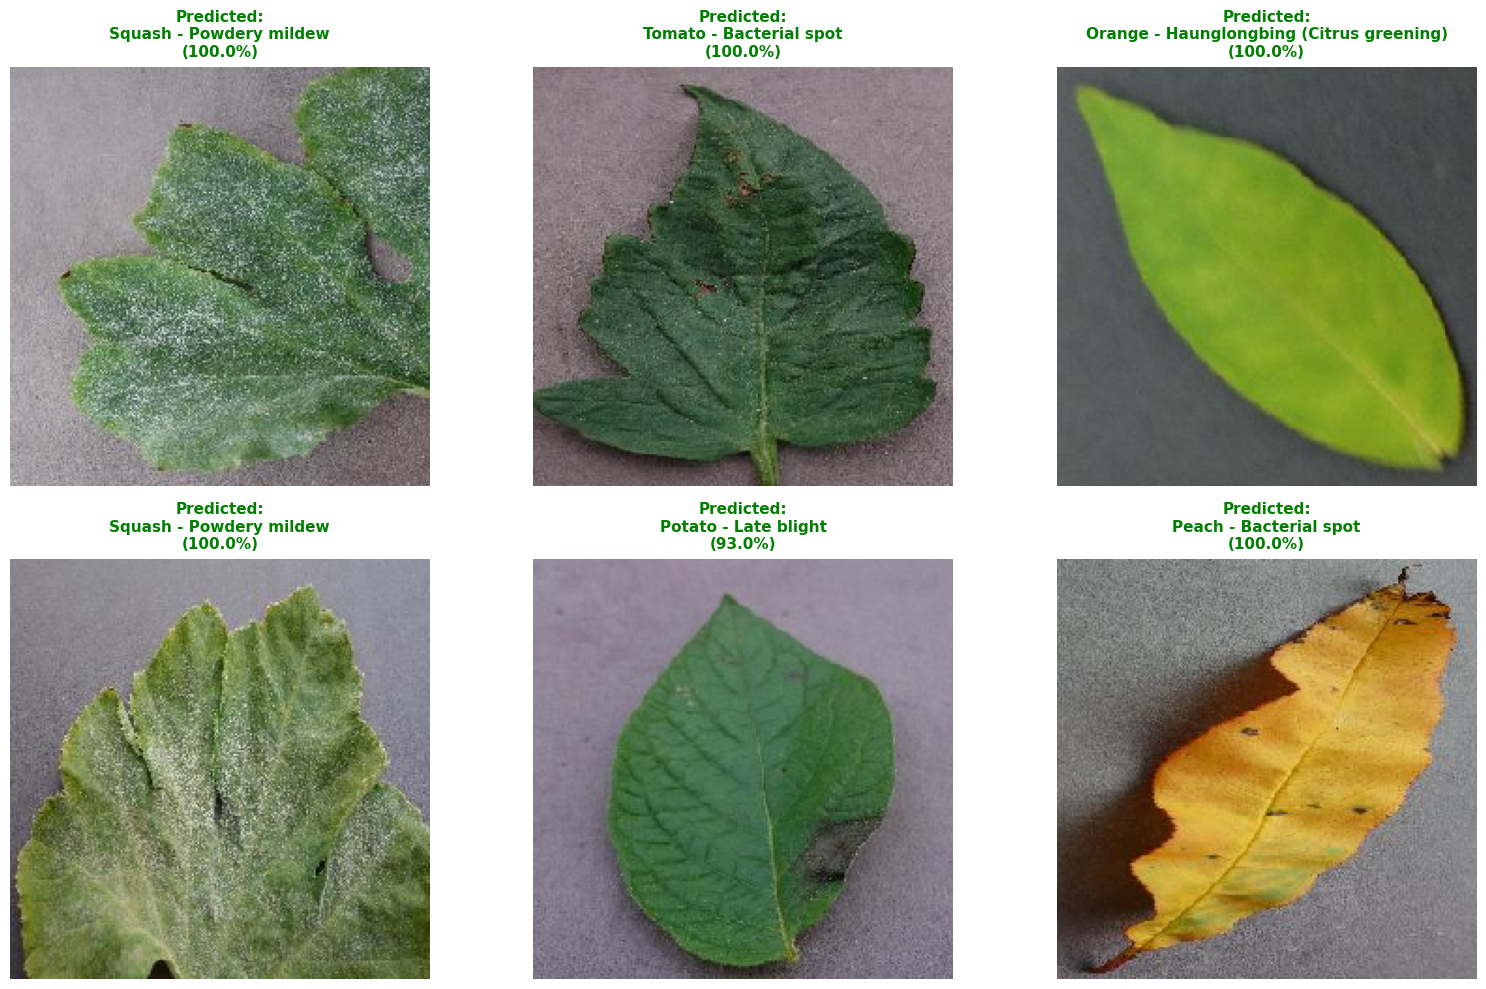

In [41]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# --- AUTOMATED FRESH SPECIMEN ACQUISITION ---
test_scan_dir = "/content/isolated_test_samples"

# Re-initialize clean temporary folder structures
if os.path.exists(test_scan_dir):
    shutil.rmtree(test_scan_dir)
os.makedirs(test_scan_dir)

print("⚡ Scanning remote repository sources for fresh test specimens...")
# Clone a tiny random image sequence directly from GitHub mirrors to avoid manual uploads
!git clone -q https://github.com/spMohanty/PlantVillage-Dataset.git /content/pv_source_temp

# Harvest test assets from the cloned mirror to the active path
harvest_pool = []
for root, _, files_in_dir in os.walk("/content/pv_source_temp/raw/color"):
    for f in files_in_dir:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            harvest_pool.append(os.path.join(root, f))

# Populate the target directory with a fresh selection of 6 specimens
selected_samples = random.sample(harvest_pool, 6)
for idx, source_path in enumerate(selected_samples):
    shutil.copy(source_path, os.path.join(test_scan_dir, f"specimen_{idx}.jpg"))

# Purge large temporary repository clone data
shutil.rmtree("/content/pv_source_temp")
print("✅ Automated scanning complete! Images staged successfully without manual uploads.\n")

# --- BATCH EXECUTION GRID GENERATION ---
print("🔄 Running batch inference on 6 random test images...")

# Reconstruct label lookup schema from the memory flow stream
class_indices = train_stream.class_indices
labels_lookup = {v: k for k, v in class_indices.items()}

# Prepare target 2x3 grid canvas environment layout matching specifications
rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(16, 10))
axes = axes.flatten()

all_staged_images = os.listdir(test_scan_dir)

for idx, img_name in enumerate(all_staged_images):
    img_path = os.path.join(test_scan_dir, img_name)

    # Process image metrics dynamically for the operational network input parameters
    raw_leaf = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(raw_leaf)
    normalized_tensor = np.expand_dims(img_array, axis=0) / 255.0

    # Compute active network output predictions matrix
    predictions = plant_classifier_model.predict(normalized_tensor, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_idx] * 100

    # Restructure string tags to cleanly match visual requirements formatting
    raw_label = labels_lookup[predicted_idx]
    clean_label = raw_label.replace("___", " - ").replace("_", " ")

    # Plot graphics properties out onto target canvas locations
    axes[idx].imshow(raw_leaf)
    axes[idx].axis('off')

    # Format and place labels precisely above corresponding grid elements
    axes[idx].set_title(
        f"Predicted:\n{clean_label}\n({confidence:.1f}%)",
        fontsize=11,
        color='green',
        weight='bold',
        pad=8
    )

plt.tight_layout()
plt.show()

In [42]:
import json

# Compile label indexing directly from your active training flow
labels_schema = train_stream.class_indices

# Export as an independent structural JSON file tracking parameters
with open('botanical_labels.json', 'w') as f:
    json.dump(labels_schema, f)

print("✅ 'botanical_labels.json' successfully generated and saved to environment workspace!")

✅ 'botanical_labels.json' successfully generated and saved to environment workspace!
